In [75]:
import math
import pickle

import numpy as np
import matplotlib.pyplot as plt

from scipy import signal
from scipy.ndimage import rotate
from scipy.ndimage import maximum_filter
from scipy.signal import convolve2d
from typing import Dict, List, Tuple, Sequence
from typing import List, Sequence, Tuple
from scipy import ndimage

In [43]:
# --------------------------------------------------
# Data
# --------------------------------------------------

LAYER_NAME = "d4"

TRAJECTORY_RESULTS_PATH = (
    "/Users/ais/Desktop/2026_Summer/"
    "2d_hippocampal_cells/"
    "2D-traj-results-training.pkl"
)

# --------------------------------------------------
# Analysis
# --------------------------------------------------

N_BINS = 80

GAUSSIAN_WINDOW = 9

GAUSSIAN_SIGMA = 3.0

THRESHOLD_K = 1.5

EPS = 1e-10

SKIP_TIMESTEPS = 50

BOUNDS = (0.0, 1.0, 0.0, 1.0)

In [44]:
def matlab_style_gauss2d(shape=(9,9), sigma=3.0):

    m, n = [(ss-1.)/2. for ss in shape]

    y, x = np.ogrid[-m:m+1, -n:n+1]

    h = np.exp(-(x*x+y*y)/(2*sigma*sigma))

    h[h < np.finfo(h.dtype).eps*h.max()] = 0

    if h.sum() != 0:
        h /= h.sum()

    return h

In [45]:
def occupancy_map_func(
    pos,
    reso=N_BINS//2,
    win_len=GAUSSIAN_WINDOW,
    sigma=GAUSSIAN_SIGMA,
):

    hist, _, _ = np.histogram2d(
        pos[:,0],
        pos[:,1],
        bins=reso*2,
    )

    gaussian = matlab_style_gauss2d(
        (win_len,win_len),
        sigma,
    )

    pos_prob = signal.convolve2d(
        gaussian,
        hist,
    )

    trim = win_len//2

    pos_prob = pos_prob[
        trim:-trim,
        trim:-trim,
    ]

    pos_prob /= np.nansum(pos_prob)

    return pos_prob

In [46]:
def build_firing_rate_map(
    responses: np.ndarray,
    pos: np.ndarray,
    occupancy_map: np.ndarray | None = None,
    thresh_param: float = 1.5,
    res_param: int = 80,
    gaussian_shape: Sequence[int] = (9, 9),
    gaussian_sigma: float = 3.0,
    normalization: str = "occupancy",
) -> Tuple[np.ndarray, List[float]]:
    mean_resp = np.mean(responses)
    std_resp = np.std(responses)
    thresh = mean_resp + (thresh_param * std_resp)
    firing_idx = np.flatnonzero(responses > thresh)

    xmin, xmax = float(np.min(pos[:, 0])), float(np.max(pos[:, 0]))
    ymin, ymax = float(np.min(pos[:, 1])), float(np.max(pos[:, 1]))

    x = np.linspace(xmin, xmax, res_param)
    y = np.linspace(ymin, ymax, res_param)
    firing_map = np.zeros((res_param, res_param), dtype=float)

    if firing_idx.size:
        firing_positions = pos[firing_idx, :2]
        firing_values = responses[firing_idx]

        for ii in range(len(firing_positions)):
            col = int(np.argmin(np.abs(firing_positions[ii, 0] - x)))
            row = int(np.argmin(np.abs(firing_positions[ii, 1] - y)))
            firing_map[row, col] = max(firing_values[ii], firing_map[row, col])

    if normalization == "occupancy" and occupancy_map is not None:
        occ = np.asarray(occupancy_map, dtype=float).copy()
        occ[occ == 0] = np.nan
        with np.errstate(divide="ignore", invalid="ignore"):
            firing_map = np.divide(
                firing_map,
                occ,
                out=np.zeros_like(firing_map, dtype=float),
                where=np.isfinite(occ) & (occ != 0),
            )
        firing_map = np.nan_to_num(firing_map, nan=0.0)
    else:
        max_value = float(np.nanmax(firing_map)) if firing_map.size else 0.0
        if max_value > 0:
            firing_map = firing_map / max_value

    gaussian = matlab_style_gauss2d(gaussian_shape, gaussian_sigma)
    spikes_smooth = signal.convolve2d(gaussian, firing_map)
    trim = int(gaussian_shape[0] // 2)
    spikes_smooth = spikes_smooth[trim:-trim, trim:-trim]
    extent = [xmin, xmax, ymin, ymax]
    return spikes_smooth, extent

In [47]:
def load_dataset(
    pkl_path,
    layer_name,
    skip_timesteps=SKIP_TIMESTEPS,
):
    """
    Load trajectory predictions and neural activations.

    Returns
    -------
    ground_truth : (n_traj, T, 2)
    prediction   : (n_traj, T, 2)
    positions    : (n_traj, T, 2)
    activations  : (n_traj, T, n_neurons)
    """

    with open(pkl_path, "rb") as f:
        data = pickle.load(f)

    ground_truth = np.asarray(data["ground_truth"])
    prediction = np.asarray(data["prediction"])
    activations = np.asarray(data[layer_name])

    # We analyse predicted positions
    positions = prediction.copy()

    if skip_timesteps > 0:

        ground_truth = ground_truth[:, skip_timesteps:, :]
        prediction = prediction[:, skip_timesteps:, :]
        positions = positions[:, skip_timesteps:, :]
        activations = activations[:, skip_timesteps:, :]

    return (
        ground_truth,
        prediction,
        positions,
        activations,
    )

In [48]:
def concatenate_trajectories(
    positions,
    activations,
    ground_truth,
    prediction,
    trajectory_ids,
):
    """
    Concatenate multiple trajectories into one long trajectory.
    """

    return {

        "positions": np.concatenate(
            [positions[i] for i in trajectory_ids],
            axis=0,
        ),

        "activations": np.concatenate(
            [activations[i] for i in trajectory_ids],
            axis=0,
        ),

        "ground_truth": np.concatenate(
            [ground_truth[i] for i in trajectory_ids],
            axis=0,
        ),

        "prediction": np.concatenate(
            [prediction[i] for i in trajectory_ids],
            axis=0,
        ),
    }

In [49]:
ground_truth, prediction, positions, activations = load_dataset(
    TRAJECTORY_RESULTS_PATH,
    LAYER_NAME,
)

print("Ground Truth :", ground_truth.shape)
print("Prediction   :", prediction.shape)
print("Positions    :", positions.shape)
print("Activations  :", activations.shape)

Ground Truth : (500, 450, 2)
Prediction   : (500, 450, 2)
Positions    : (500, 450, 2)
Activations  : (500, 450, 100)


In [50]:
# --------------------------------------------------
# Select trajectories
# --------------------------------------------------

selected_traj = list(range(10))
# Example:
# selected_traj = [44, 216, 219, 325, 384]

combined_data = concatenate_trajectories(
    positions,
    activations,
    ground_truth,
    prediction,
    selected_traj,
)

print("Combined data created.\n")

for key, value in combined_data.items():
    print(f"{key:15s}: {value.shape}")

Combined data created.

positions      : (4500, 2)
activations    : (4500, 100)
ground_truth   : (4500, 2)
prediction     : (4500, 2)


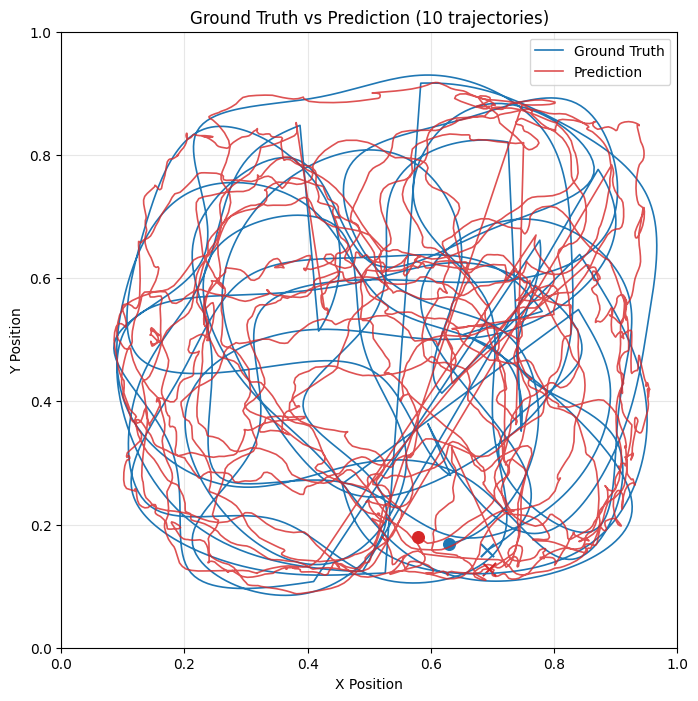

In [51]:
plt.figure(figsize=(8, 8))

# --------------------------------------------------
# Ground Truth
# --------------------------------------------------

plt.plot(
    combined_data["ground_truth"][:, 0],
    combined_data["ground_truth"][:, 1],
    color="tab:blue",
    linewidth=1.2,
    label="Ground Truth",
)

# --------------------------------------------------
# Prediction
# --------------------------------------------------

plt.plot(
    combined_data["prediction"][:, 0],
    combined_data["prediction"][:, 1],
    color="tab:red",
    linewidth=1.2,
    alpha=0.8,
    label="Prediction",
)

# --------------------------------------------------
# Starting positions
# --------------------------------------------------

plt.scatter(
    combined_data["ground_truth"][0, 0],
    combined_data["ground_truth"][0, 1],
    color="tab:blue",
    marker="o",
    s=70,
)

plt.scatter(
    combined_data["prediction"][0, 0],
    combined_data["prediction"][0, 1],
    color="tab:red",
    marker="o",
    s=70,
)

# --------------------------------------------------
# Ending positions
# --------------------------------------------------

plt.scatter(
    combined_data["ground_truth"][-1, 0],
    combined_data["ground_truth"][-1, 1],
    color="tab:blue",
    marker="x",
    s=90,
)

plt.scatter(
    combined_data["prediction"][-1, 0],
    combined_data["prediction"][-1, 1],
    color="tab:red",
    marker="x",
    s=90,
)

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.gca().set_aspect("equal")

plt.xlabel("X Position")
plt.ylabel("Y Position")

plt.title(
    f"Ground Truth vs Prediction ({len(selected_traj)} trajectories)"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

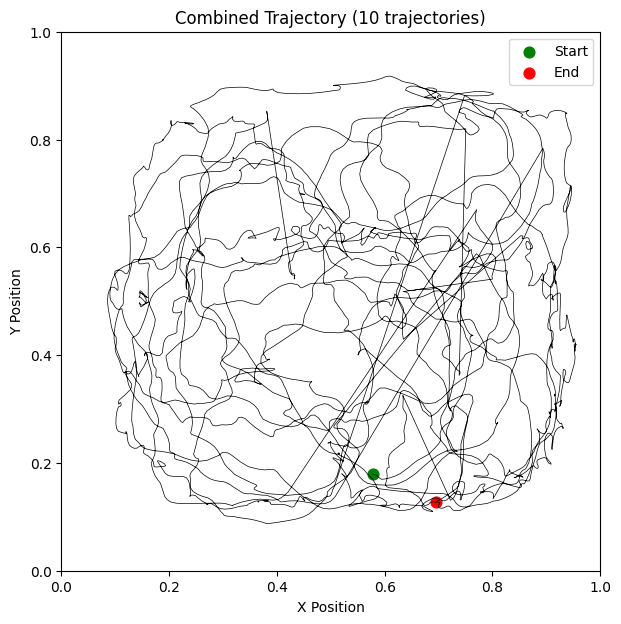

In [52]:
plt.figure(figsize=(7,7))

plt.plot(
    combined_data["positions"][:,0],
    combined_data["positions"][:,1],
    color="black",
    lw=0.5,
)

plt.scatter(
    combined_data["positions"][0,0],
    combined_data["positions"][0,1],
    c="green",
    s=60,
    label="Start",
)

plt.scatter(
    combined_data["positions"][-1,0],
    combined_data["positions"][-1,1],
    c="red",
    s=60,
    label="End",
)

plt.xlim(0,1)
plt.ylim(0,1)

plt.gca().set_aspect("equal")

plt.xlabel("X Position")
plt.ylabel("Y Position")

plt.title(
    f"Combined Trajectory ({len(selected_traj)} trajectories)"
)

plt.legend()

plt.show()

In [53]:
# --------------------------------------------------
# Occupancy Map
# --------------------------------------------------

occupancy_map = occupancy_map_func(
    combined_data["positions"],
    reso=N_BINS // 2,
    win_len=GAUSSIAN_WINDOW,
    sigma=GAUSSIAN_SIGMA,
)

print("Occupancy Map Shape :", occupancy_map.shape)

Occupancy Map Shape : (80, 80)


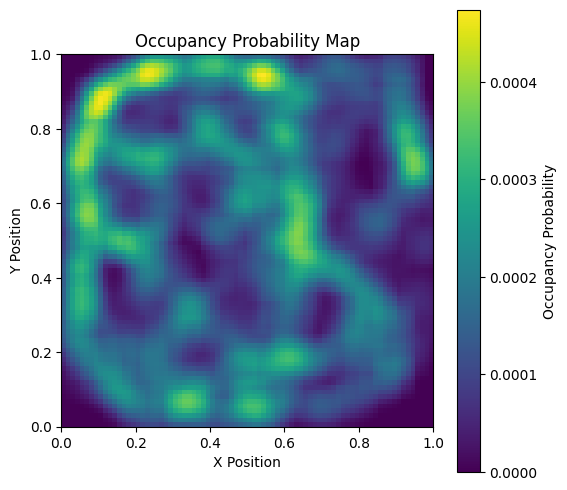

In [54]:
plt.figure(figsize=(6,6))

plt.imshow(
    occupancy_map,
    origin="lower",
    extent=[0,1,0,1],
    cmap="viridis",
)

plt.xlabel("X Position")
plt.ylabel("Y Position")

plt.title("Occupancy Probability Map")

plt.colorbar(label="Occupancy Probability")

plt.gca().set_aspect("equal")

plt.show()

In [55]:
neuron = 0

responses = combined_data["activations"][:, neuron]

rate_map, extent = build_firing_rate_map(
    responses=responses,
    pos=combined_data["positions"],
    occupancy_map=occupancy_map,
)

print(rate_map.shape)

(80, 80)


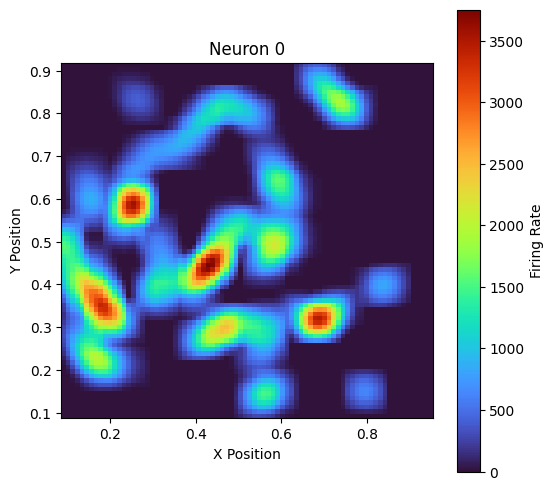

In [56]:
fig, ax = plt.subplots(figsize=(6,6))

im = ax.imshow(
    rate_map,
    origin="lower",
    extent=extent,
    cmap="turbo",
)

ax.set_xlabel("X Position")
ax.set_ylabel("Y Position")

ax.set_title(f"Neuron {neuron}")

fig.colorbar(
    im,
    ax=ax,
    label="Firing Rate",
)

plt.show()

In [57]:
EPS = 1e-10

def spatial_information(
    rate_map,
    occupancy_map,
):
    """
    Spatial Information (Skaggs et al., 1993)

    Parameters
    ----------
    rate_map : (N,N)
        Smoothed firing-rate map

    occupancy_map : (N,N)
        Probability occupancy map (sum = 1)

    Returns
    -------
    Spatial Information (bits/spike)
    """

    occ = occupancy_map.astype(float)

    occ = occ / np.sum(occ)

    valid = (
        (~np.isnan(rate_map))
        &
        (occ > 0)
        &
        (rate_map > 0)
    )

    if valid.sum() == 0:
        return np.nan

    p = occ[valid]

    r = rate_map[valid]

    mean_rate = np.sum(
        p * r
    )

    if mean_rate < EPS:
        return np.nan

    ratio = r / mean_rate

    SI = np.sum(
        p *
        ratio *
        np.log2(ratio)
    )

    return SI

In [58]:
def sparsity(
    rate_map,
    occupancy_map,
):
    """
    Population Sparsity
    """

    occ = occupancy_map.astype(float)

    occ = occ / np.sum(occ)

    valid = (
        (~np.isnan(rate_map))
        &
        (occ > 0)
    )

    if valid.sum() == 0:
        return np.nan

    p = occ[valid]

    r = rate_map[valid]

    mean_rate = np.sum(
        p * r
    )

    mean_rate_sq = np.sum(
        p * r**2
    )

    if mean_rate_sq < EPS:
        return np.nan

    return (mean_rate**2) / mean_rate_sq

In [59]:
si = spatial_information(
    rate_map,
    occupancy_map,
)

sp = sparsity(
    rate_map,
    occupancy_map,
)

print(f"Spatial Information : {si:.4f} bits/spike")
print(f"Sparsity           : {sp:.4f}")

Spatial Information : 1.2809 bits/spike
Sparsity           : 0.3253


In [60]:
# --------------------------------------------------
# Analyse every neuron
# --------------------------------------------------

results = []

n_neurons = combined_data["activations"].shape[1]

print(f"Number of neurons : {n_neurons}")

for neuron in range(n_neurons):

    # -----------------------------------------
    # Responses for one neuron
    # -----------------------------------------

    responses = combined_data["activations"][:, neuron]

    # -----------------------------------------
    # Build firing-rate map
    # -----------------------------------------

    rate_map, extent = build_firing_rate_map(
        responses=responses,
        pos=combined_data["positions"],
        occupancy_map=occupancy_map,
    )

    # -----------------------------------------
    # Place-cell metrics
    # -----------------------------------------

    si = spatial_information(
        rate_map,
        occupancy_map,
    )

    sp = sparsity(
        rate_map,
        occupancy_map,
    )

    # -----------------------------------------
    # Store results
    # -----------------------------------------

    results.append(
        {
            "Neuron": neuron,
            "Responses": responses,
            "Rate Map": rate_map,
            "Extent": extent,
            "Spatial Information": si,
            "Sparsity": sp,
        }
    )

print(f"\nFinished analysing {len(results)} neurons.")

Number of neurons : 100

Finished analysing 100 neurons.


In [61]:
results = sorted(
    results,
    key=lambda x: x["Spatial Information"],
    reverse=True,
)

print("Top 10 neurons by Spatial Information\n")

for r in results[:10]:

    print(
        f"Neuron {r['Neuron']:3d} | "
        f"SI = {r['Spatial Information']:.3f} | "
        f"Sparsity = {r['Sparsity']:.3f}"
    )

Top 10 neurons by Spatial Information

Neuron  12 | SI = 3.117 | Sparsity = 0.070
Neuron  53 | SI = 2.877 | Sparsity = 0.078
Neuron  96 | SI = 2.863 | Sparsity = 0.090
Neuron  49 | SI = 2.855 | Sparsity = 0.096
Neuron  38 | SI = 2.827 | Sparsity = 0.100
Neuron  73 | SI = 2.739 | Sparsity = 0.105
Neuron  91 | SI = 2.656 | Sparsity = 0.090
Neuron  88 | SI = 2.650 | Sparsity = 0.089
Neuron   9 | SI = 2.650 | Sparsity = 0.095
Neuron  90 | SI = 2.618 | Sparsity = 0.085


In [62]:
# --------------------------------------------------
# Place-cell thresholds
# --------------------------------------------------

SI_THRESHOLD = 0.50

SPARSITY_THRESHOLD = 0.50

place_cells = [

    r

    for r in results

    if (
        r["Spatial Information"] >= SI_THRESHOLD
        and
        r["Sparsity"] <= SPARSITY_THRESHOLD
    )
]

print(f"Place cells found : {len(place_cells)}")

Place cells found : 100


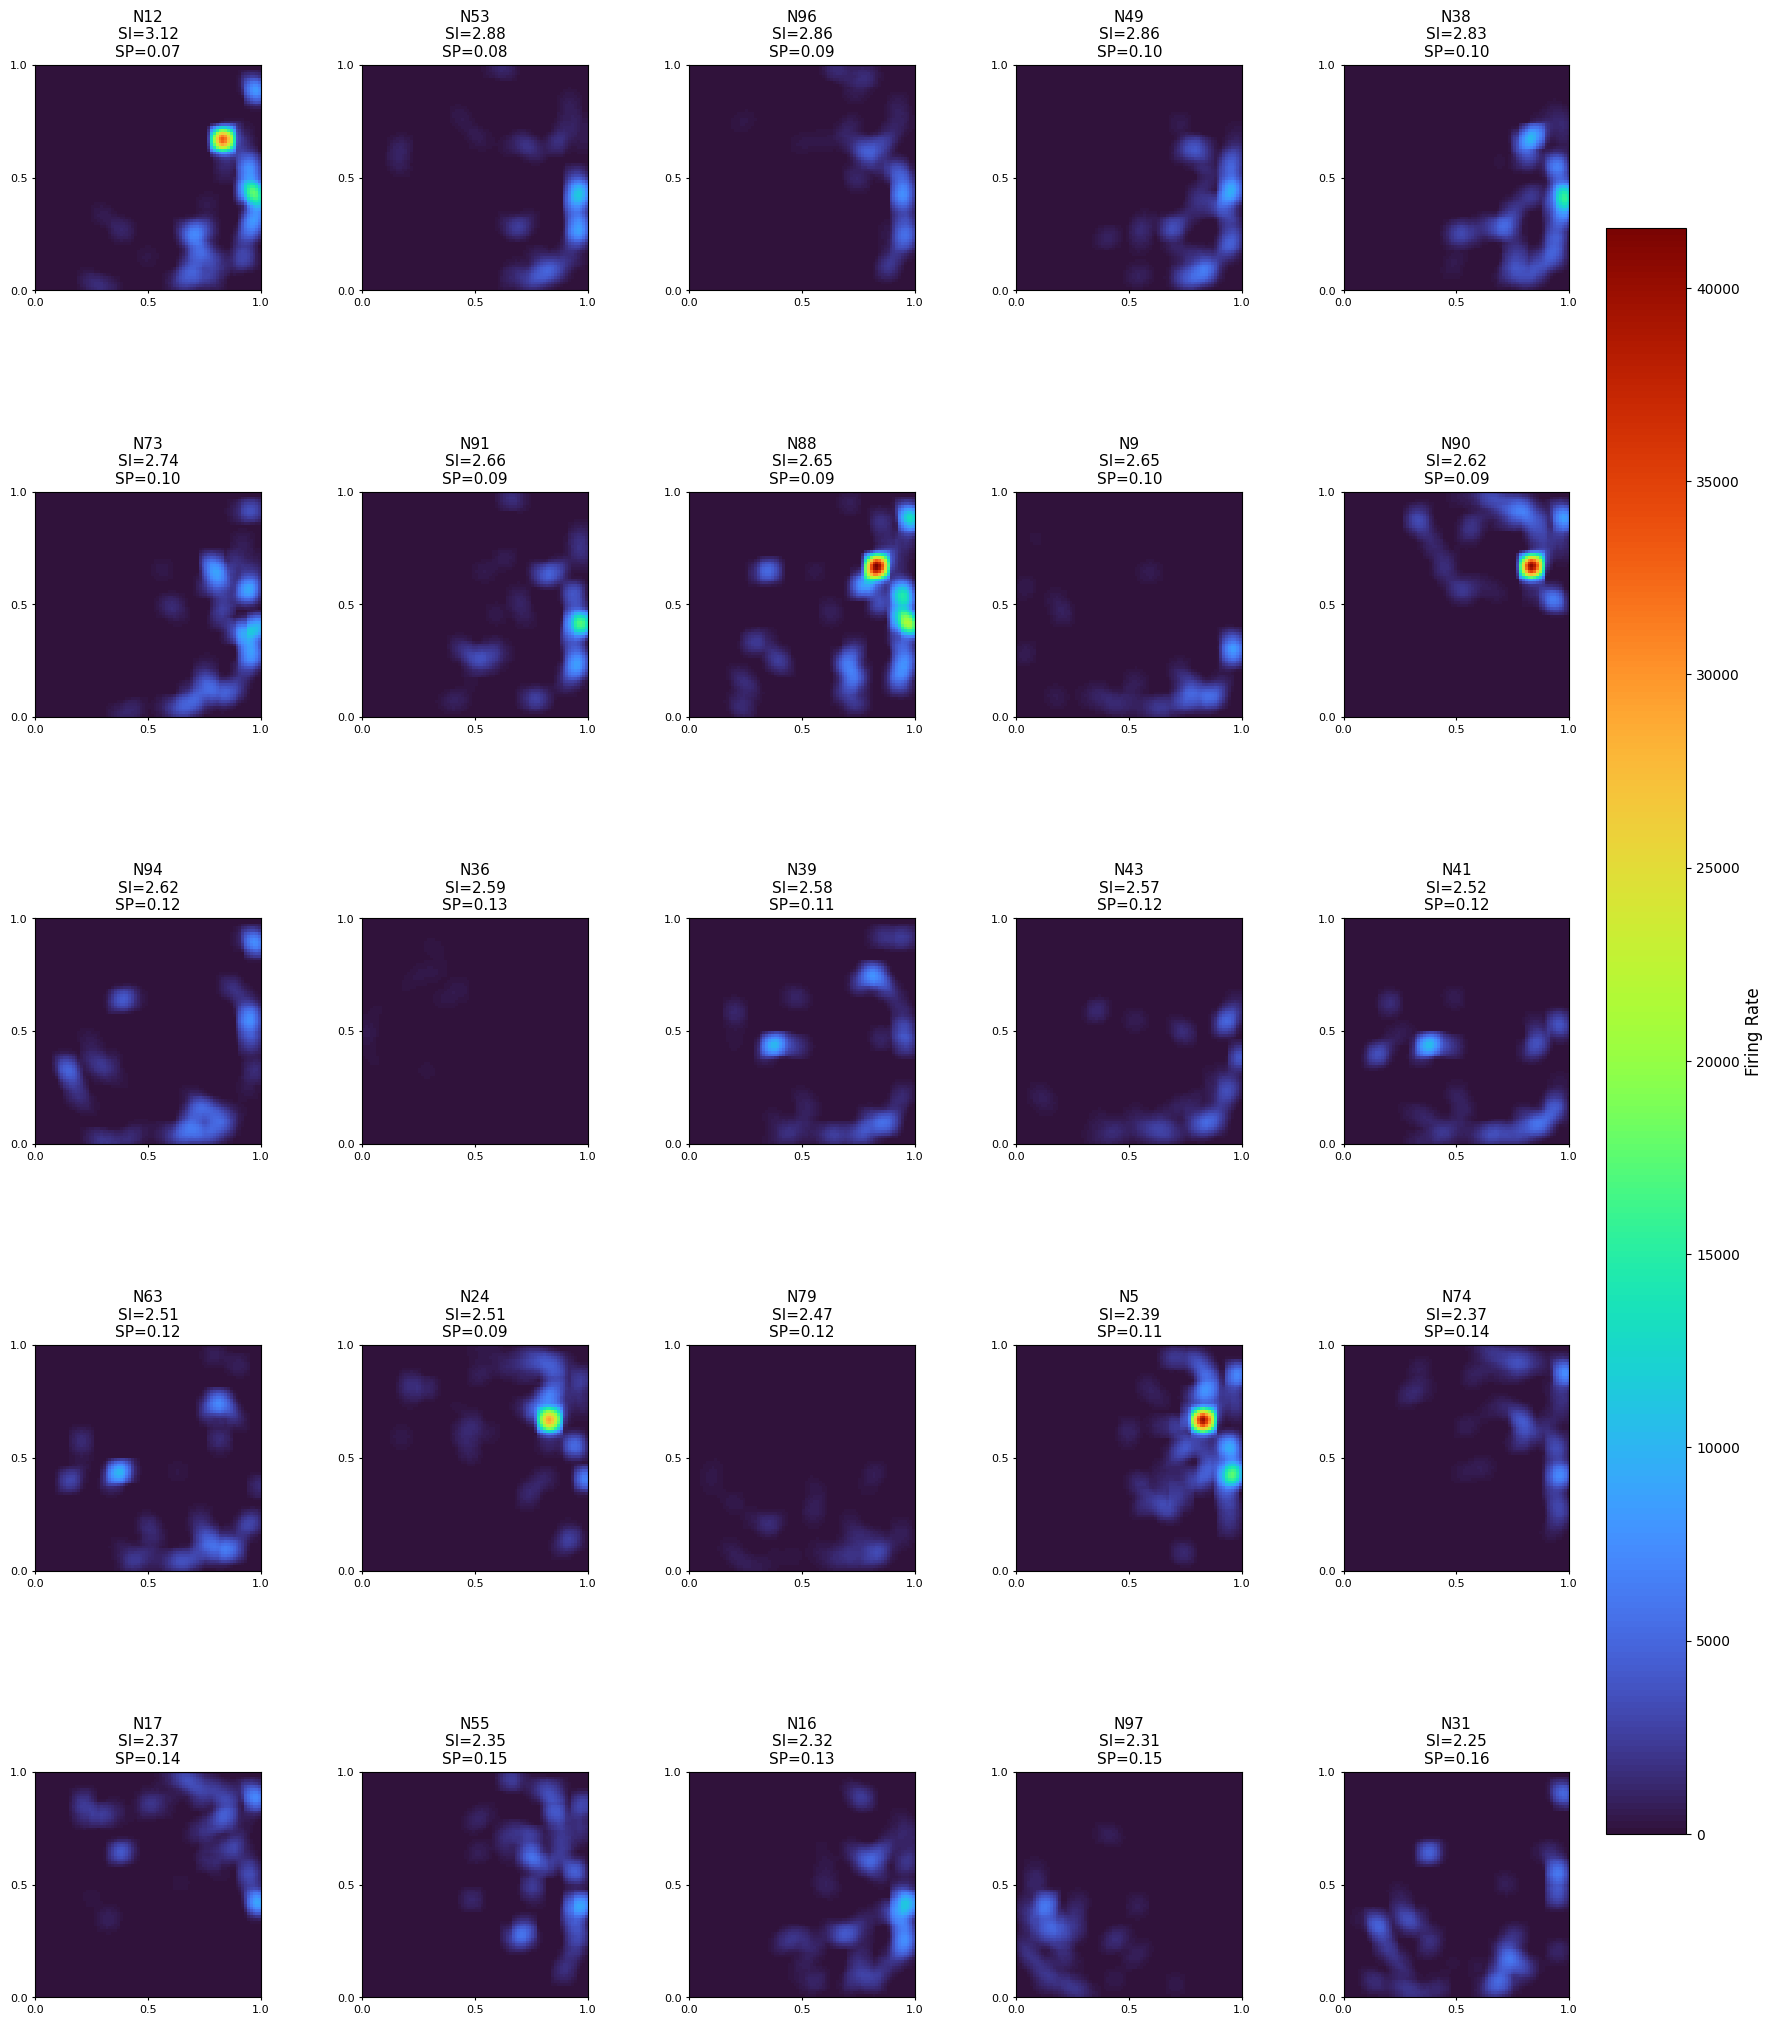

In [63]:
top25 = place_cells[:25]

fig, axes = plt.subplots(
    5,
    5,
    figsize=(22, 22),
)

plt.subplots_adjust(
    left=0.06,
    right=0.90,
    bottom=0.06,
    top=0.95,
    wspace=0.45,
    hspace=0.70,
)

axes = axes.ravel()

vmax = max(
    np.nanmax(r["Rate Map"])
    for r in top25
)

for ax, neuron in zip(axes, top25):

    im = ax.imshow(
        neuron["Rate Map"],
        origin="lower",
        extent=[0, 1, 0, 1],          # Fixed arena
        cmap="turbo",
        aspect="equal",
        interpolation="nearest",
        vmin=0,
        vmax=vmax,
    )

    ax.set_title(
        f"N{neuron['Neuron']}\n"
        f"SI={neuron['Spatial Information']:.2f}\n"
        f"SP={neuron['Sparsity']:.2f}",
        fontsize=11,
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_xticks([0, 0.5, 1])
    ax.set_yticks([0, 0.5, 1])

    ax.tick_params(
        labelsize=8,
        length=2,
    )

cbar = fig.colorbar(
    im,
    ax=axes.tolist(),
    shrink=0.82,
    pad=0.02,
)

cbar.set_label(
    "Firing Rate",
    fontsize=12,
)

plt.show()

In [64]:
# --------------------------------------------------
# Analyse every neuron
# --------------------------------------------------

results = []

n_neurons = combined_data["activations"].shape[1]

print(f"Number of neurons : {n_neurons}")

for neuron in range(n_neurons):

    responses = combined_data["activations"][:, neuron]

    rate_map, extent = build_firing_rate_map(
        responses=responses,
        pos=combined_data["positions"],
        occupancy_map=occupancy_map,
    )

    si = spatial_information(
        rate_map,
        occupancy_map,
    )

    sp = sparsity(
        rate_map,
        occupancy_map,
    )

    # -----------------------------------------
    # NEW
    # -----------------------------------------

    mean_rate = np.nanmean(rate_map)

    peak_rate = np.nanmax(rate_map)

    active_bins = np.count_nonzero(rate_map > 0)

    # -----------------------------------------

    results.append(
        {
            "Neuron": neuron,
            "Responses": responses,
            "Rate Map": rate_map,
            "Extent": extent,
            "Spatial Information": si,
            "Sparsity": sp,
            "Mean Rate": mean_rate,
            "Peak Rate": peak_rate,
            "Active Bins": active_bins,
        }
    )

print(f"\nFinished analysing {len(results)} neurons.")

Number of neurons : 100

Finished analysing 100 neurons.


In [65]:
results = sorted(
    results,
    key=lambda x: x["Spatial Information"],
    reverse=True,
)

print("\nTop 10 neurons\n")

for r in results[:10]:

    print(
        f"N{r['Neuron']:3d} | "
        f"SI={r['Spatial Information']:.3f} | "
        f"SP={r['Sparsity']:.3f} | "
        f"Mean={r['Mean Rate']:.1f} | "
        f"Peak={r['Peak Rate']:.1f} | "
        f"Bins={r['Active Bins']}"
    )


Top 10 neurons

N 12 | SI=3.117 | SP=0.070 | Mean=870.9 | Peak=33227.8 | Bins=2007
N 53 | SI=2.877 | SP=0.078 | Mean=399.6 | Peak=11454.5 | Bins=2124
N 96 | SI=2.863 | SP=0.090 | Mean=329.1 | Peak=7567.6 | Bins=2035
N 49 | SI=2.855 | SP=0.096 | Mean=463.3 | Peak=9600.4 | Bins=2097
N 38 | SI=2.827 | SP=0.100 | Mean=636.3 | Peak=15712.7 | Bins=1978
N 73 | SI=2.739 | SP=0.105 | Mean=642.7 | Peak=11460.9 | Bins=2040
N 91 | SI=2.656 | SP=0.090 | Mean=468.8 | Peak=17047.2 | Bins=2160
N 88 | SI=2.650 | SP=0.089 | Mean=1229.8 | Peak=41541.0 | Bins=2675
N  9 | SI=2.650 | SP=0.095 | Mean=265.0 | Peak=8329.2 | Bins=1888
N 90 | SI=2.618 | SP=0.085 | Mean=709.7 | Peak=40687.8 | Bins=1887


In [66]:
def point_corr(
    map1: np.ndarray,
    map2: np.ndarray,
    row_off: int,
    col_off: int,
    bins: int,
) -> float:
    num_rows = bins - abs(row_off)
    num_cols = bins - abs(col_off)

    if row_off > 0:
        r_st1 = abs(row_off)
        r_st2 = 0
    else:
        r_st1 = 0
        r_st2 = abs(row_off)

    if col_off > 0:
        c_st1 = abs(col_off)
        c_st2 = 0
    else:
        c_st1 = 0
        c_st2 = abs(col_off)

    block1 = map1[r_st1 : r_st1 + num_rows, c_st1 : c_st1 + num_cols]
    block2 = map2[r_st2 : r_st2 + num_rows, c_st2 : c_st2 + num_cols]
    valid = ~np.isnan(block1) & ~np.isnan(block2)
    nb = int(valid.sum())
    if nb < 20:
        return 0.0

    x = block1[valid]
    y = block2[valid]
    sum_x = x.sum()
    sum_y = y.sum()
    sum_xy = np.sum(x * y)
    sum_x2 = np.sum(x * x)
    sum_y2 = np.sum(y * y)

    var_x = sum_x2 - (sum_x * sum_x) / nb
    var_y = sum_y2 - (sum_y * sum_y) / nb
    cov_xy = sum_xy - (sum_x * sum_y) / nb

    if (var_x <= 0 <= var_y) or (var_y <= 0 <= var_x):
        return 0.0
    if var_x <= 0 or var_y <= 0:
        return 0.0

    return float(cov_xy / math.sqrt(var_x * var_y))


In [67]:
def correlation_map(map1: np.ndarray, map2: np.ndarray) -> np.ndarray:
    bins = map1.shape[0]
    n = bins + round(0.64 * bins)
    if n % 2 == 0:
        n -= 1
    center_bin = (n + 1) // 2

    corr = np.zeros((n, n), dtype=float)
    for ii in range(n):
        row_off = ii + 1 - center_bin
        for jj in range(n):
            col_off = jj + 1 - center_bin
            corr[ii, jj] = point_corr(map1, map2, row_off, col_off, bins)
    return corr

In [68]:
def corrcoef2(a: np.ndarray, b: np.ndarray) -> float:
    a_flat = np.asarray(a, dtype=float).ravel()
    b_flat = np.asarray(b, dtype=float).ravel()
    valid = ~np.isnan(a_flat) & ~np.isnan(b_flat)
    if valid.sum() < 2:
        return 0.0
    a_flat = a_flat[valid]
    b_flat = b_flat[valid]
    if np.std(a_flat) == 0 or np.std(b_flat) == 0:
        return 0.0
    return float(np.corrcoef(a_flat, b_flat)[0, 1])

In [69]:
def _crop_center(rotated: np.ndarray, target_shape: Tuple[int, int]) -> np.ndarray:
    start0 = (rotated.shape[0] - target_shape[0]) // 2
    start1 = (rotated.shape[1] - target_shape[1]) // 2
    return rotated[start0 : start0 + target_shape[0], start1 : start1 + target_shape[1]]


In [70]:
def _regional_maxima(arr: np.ndarray) -> np.ndarray:
    max_filtered = ndimage.maximum_filter(arr, size=3, mode="nearest")
    return (arr == max_filtered) & np.isfinite(arr)

In [71]:
def gridscore(masked_corr: np.ndarray) -> float:
    c60 = ndimage.rotate(masked_corr, 60, reshape=True)
    c60_2 = _crop_center(c60, masked_corr.shape)
    r60 = corrcoef2(masked_corr, c60_2)

    c120 = ndimage.rotate(masked_corr, 120, reshape=True)
    c120_2 = _crop_center(c120, masked_corr.shape)
    r120 = corrcoef2(masked_corr, c120_2)

    c30 = ndimage.rotate(masked_corr, 30, reshape=True)
    c30_2 = _crop_center(c30, masked_corr.shape)
    r30 = corrcoef2(masked_corr, c30_2)

    c90 = ndimage.rotate(masked_corr, 90, reshape=False)
    r90 = corrcoef2(masked_corr, c90)

    c150 = ndimage.rotate(masked_corr, 150, reshape=True)
    c150_2 = _crop_center(c150, masked_corr.shape)
    r150 = corrcoef2(masked_corr, c150_2)

    return float(min(r60, r120) - max(r30, r90, r150))


In [72]:
def build_autocorrelation_ring(
    spikes_smooth: np.ndarray,
    win_len: int = 7,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    rotated_img = ndimage.rotate(spikes_smooth, 90, reshape=True)
    trim = round(win_len / 2)
    rotated_img = rotated_img[trim:-trim, trim:-trim]

    corr = correlation_map(rotated_img, rotated_img)
    rows, cols = corr.shape
    central_peak = np.array([0.5 * (rows + 1), 0.5 * (cols + 1)], dtype=float)

    maxima = _regional_maxima(corr)
    peakx, peaky = np.where(maxima)
    if peakx.size == 0:
        return corr, corr, rotated_img

    peak_matrix = np.column_stack((peakx + 1, peaky + 1))
    distances = np.linalg.norm(peak_matrix - central_peak, axis=1)
    distascending = np.sort(distances)
    if len(distascending) < 6:
        return corr, corr, rotated_img

    radius1 = np.max(distascending[1 : min(6, len(distascending))]) + 3
    rr, cc = np.meshgrid(np.arange(1, len(corr) + 1), np.arange(1, len(corr) + 1))
    circlemask1 = np.sqrt((rr - central_peak[0]) ** 2 + (cc - central_peak[1]) ** 2) <= radius1
    corr_ring = corr * circlemask1

    radius2 = 12
    circlemask2 = np.sqrt((rr - central_peak[0]) ** 2 + (cc - central_peak[1]) ** 2) <= radius2
    corr_ring = corr_ring * (~circlemask2)
    return corr, corr_ring, rotated_img

In [73]:
def score_single_neuron(
    responses: np.ndarray,
    pos: np.ndarray,
    occupancy_map: np.ndarray,
    num_shuffles: int,
    rng: np.random.Generator,
    thresh_param: float,
    res_param: int,
) -> Dict[str, object]:
    map_res = int(occupancy_map.shape[0]) if occupancy_map is not None else res_param
    original_map, original_extent = build_firing_rate_map(
        responses,
        pos,
        occupancy_map,
        thresh_param=thresh_param,
        res_param=map_res,
    )
    autocorr_map, autocorr_ring, _ = build_autocorrelation_ring(original_map)
    original_hgs = gridscore(autocorr_ring)

    shuffled_scores = np.zeros(num_shuffles, dtype=float)
    for shuffle_idx in range(num_shuffles):
        shuffled_resp = rng.permutation(responses)
        shuffled_map, _ = build_firing_rate_map(
            shuffled_resp,
            pos,
            occupancy_map,
            thresh_param=thresh_param,
            res_param=map_res,
        )
        _, shuffled_ring, _ = build_autocorrelation_ring(shuffled_map)
        shuffled_scores[shuffle_idx] = gridscore(shuffled_ring)

    threshold_95 = float(np.nanpercentile(shuffled_scores, 95))
    is_grid = bool(np.isfinite(original_hgs) and original_hgs > threshold_95)

    return {
        "original_hgs": float(original_hgs),
        "shuffle_threshold_95": threshold_95,
        "is_grid_cell": is_grid,
        "shuffled_hgs": shuffled_scores,
        "original_map": original_map,
        "original_extent": original_extent,
        "autocorr_map": autocorr_map,
        "autocorr_ring": autocorr_ring,
    }


In [77]:
rng = np.random.default_rng(0)

test_results = []

for neuron in range(10):

    print(f"Neuron {neuron}")

    responses = combined_data["activations"][:, neuron]

    grid = score_single_neuron(
        responses=responses,
        pos=combined_data["positions"],
        occupancy_map=occupancy_map,
        num_shuffles=10,      # Keep this small for testing
        rng=rng,
        thresh_param=THRESHOLD_K,
        res_param=N_BINS,
    )

    test_results.append({
        "Neuron": neuron,
        "Grid Score": grid["original_hgs"],
        "Threshold95": grid["shuffle_threshold_95"],
        "Grid Cell": grid["is_grid_cell"],
    })

print("Done!")

Neuron 0
Neuron 1
Neuron 2
Neuron 3
Neuron 4
Neuron 5
Neuron 6
Neuron 7
Neuron 8
Neuron 9
Done!


In [78]:
for r in test_results:

    print(
        f"N{r['Neuron']:2d} | "
        f"Grid Score = {r['Grid Score']:.3f} | "
        f"Threshold = {r['Threshold95']:.3f} | "
        f"Grid Cell = {r['Grid Cell']}"
    )

N 0 | Grid Score = -0.344 | Threshold = 0.198 | Grid Cell = False
N 1 | Grid Score = -0.136 | Threshold = 0.084 | Grid Cell = False
N 2 | Grid Score = 0.013 | Threshold = -0.011 | Grid Cell = True
N 3 | Grid Score = -0.407 | Threshold = 0.157 | Grid Cell = False
N 4 | Grid Score = -0.329 | Threshold = -0.017 | Grid Cell = False
N 5 | Grid Score = -0.073 | Threshold = 0.247 | Grid Cell = False
N 6 | Grid Score = 0.028 | Threshold = 0.298 | Grid Cell = False
N 7 | Grid Score = 0.099 | Threshold = 0.020 | Grid Cell = True
N 8 | Grid Score = 0.200 | Threshold = -0.050 | Grid Cell = True
N 9 | Grid Score = -0.316 | Threshold = -0.014 | Grid Cell = False


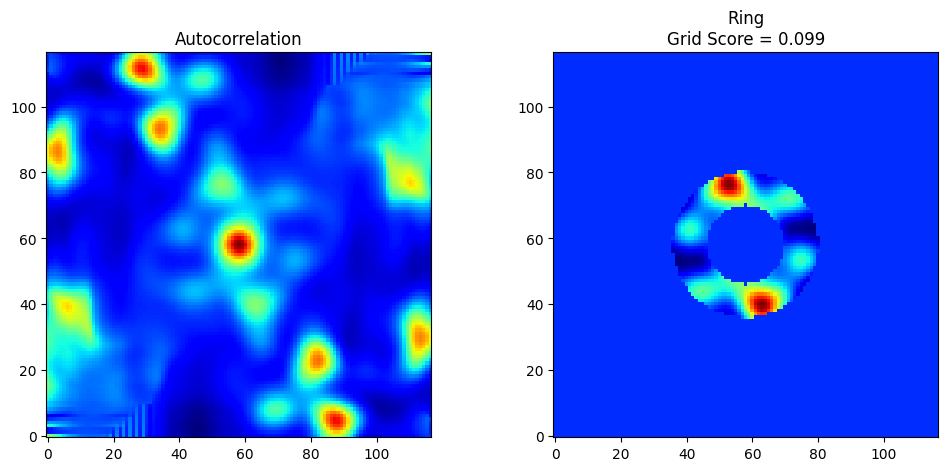

In [80]:
neuron = 7

responses = combined_data["activations"][:, neuron]

grid = score_single_neuron(
    responses,
    combined_data["positions"],
    occupancy_map,
    num_shuffles=10,
    rng=np.random.default_rng(0),
    thresh_param=THRESHOLD_K,
    res_param=N_BINS,
)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(
    grid["autocorr_map"],
    origin="lower",
    cmap="jet",
)
ax[0].set_title("Autocorrelation")

ax[1].imshow(
    grid["autocorr_ring"],
    origin="lower",
    cmap="jet",
)
ax[1].set_title(
    f"Ring\nGrid Score = {grid['original_hgs']:.3f}"
)

plt.show()

In [81]:
rng = np.random.default_rng(0)

grid_results = []

n_neurons = combined_data["activations"].shape[1]

print(f"Scoring {n_neurons} neurons...")

for neuron in range(n_neurons):

    if neuron % 10 == 0:
        print(f"Processed {neuron}/{n_neurons}")

    responses = combined_data["activations"][:, neuron]

    grid = score_single_neuron(
        responses=responses,
        pos=combined_data["positions"],
        occupancy_map=occupancy_map,
        num_shuffles=10,
        rng=rng,
        thresh_param=THRESHOLD_K,
        res_param=N_BINS,
    )

    grid_results.append({
        "Neuron": neuron,
        "Grid Score": grid["original_hgs"],
        "Threshold95": grid["shuffle_threshold_95"],
        "Grid Cell": grid["is_grid_cell"],
        "Autocorrelation": grid["autocorr_map"],
        "Autocorrelation Ring": grid["autocorr_ring"],
    })

print("\nFinished!")

Scoring 100 neurons...
Processed 0/100
Processed 10/100
Processed 20/100
Processed 30/100
Processed 40/100
Processed 50/100
Processed 60/100
Processed 70/100
Processed 80/100
Processed 90/100

Finished!


In [82]:
grid_cells = [g for g in grid_results if g["Grid Cell"]]

print(f"Total neurons : {len(grid_results)}")
print(f"Grid cells    : {len(grid_cells)}")

print("\nDetected grid cells:")

for g in grid_cells:
    print(
        f"Neuron {g['Neuron']:3d} | "
        f"Grid Score = {g['Grid Score']:.3f} | "
        f"Threshold = {g['Threshold95']:.3f}"
    )

Total neurons : 100
Grid cells    : 19

Detected grid cells:
Neuron   2 | Grid Score = 0.013 | Threshold = -0.011
Neuron   7 | Grid Score = 0.099 | Threshold = 0.020
Neuron   8 | Grid Score = 0.200 | Threshold = -0.050
Neuron  11 | Grid Score = 0.218 | Threshold = -0.067
Neuron  12 | Grid Score = 0.132 | Threshold = 0.096
Neuron  20 | Grid Score = 0.570 | Threshold = -0.060
Neuron  29 | Grid Score = 0.148 | Threshold = 0.034
Neuron  33 | Grid Score = 0.338 | Threshold = -0.009
Neuron  51 | Grid Score = 0.065 | Threshold = -0.087
Neuron  53 | Grid Score = -0.047 | Threshold = -0.048
Neuron  55 | Grid Score = 0.031 | Threshold = 0.023
Neuron  58 | Grid Score = 0.008 | Threshold = -0.107
Neuron  63 | Grid Score = 0.311 | Threshold = 0.180
Neuron  66 | Grid Score = 0.018 | Threshold = 0.011
Neuron  67 | Grid Score = -0.022 | Threshold = -0.073
Neuron  73 | Grid Score = 0.039 | Threshold = 0.013
Neuron  79 | Grid Score = 0.020 | Threshold = -0.072
Neuron  93 | Grid Score = 0.053 | Threshold

In [83]:
grid_results = sorted(
    grid_results,
    key=lambda x: x["Grid Score"],
    reverse=True,
)

print("Top 20 Grid Scores\n")

for g in grid_results[:20]:

    print(
        f"Neuron {g['Neuron']:3d} | "
        f"Grid Score = {g['Grid Score']:.3f} | "
        f"Threshold = {g['Threshold95']:.3f} | "
        f"Grid Cell = {g['Grid Cell']}"
    )

Top 20 Grid Scores

Neuron  20 | Grid Score = 0.570 | Threshold = -0.060 | Grid Cell = True
Neuron  33 | Grid Score = 0.338 | Threshold = -0.009 | Grid Cell = True
Neuron  63 | Grid Score = 0.311 | Threshold = 0.180 | Grid Cell = True
Neuron  24 | Grid Score = 0.250 | Threshold = 0.290 | Grid Cell = False
Neuron  11 | Grid Score = 0.218 | Threshold = -0.067 | Grid Cell = True
Neuron  98 | Grid Score = 0.205 | Threshold = 0.145 | Grid Cell = True
Neuron   8 | Grid Score = 0.200 | Threshold = -0.050 | Grid Cell = True
Neuron  29 | Grid Score = 0.148 | Threshold = 0.034 | Grid Cell = True
Neuron  10 | Grid Score = 0.135 | Threshold = 0.172 | Grid Cell = False
Neuron  12 | Grid Score = 0.132 | Threshold = 0.096 | Grid Cell = True
Neuron  82 | Grid Score = 0.132 | Threshold = 0.215 | Grid Cell = False
Neuron   7 | Grid Score = 0.099 | Threshold = 0.020 | Grid Cell = True
Neuron  18 | Grid Score = 0.074 | Threshold = 0.095 | Grid Cell = False
Neuron  51 | Grid Score = 0.065 | Threshold = -0.

In [85]:
print(grid_results[0].keys())

dict_keys(['Neuron', 'Grid Score', 'Threshold95', 'Grid Cell', 'Autocorrelation', 'Autocorrelation Ring'])


Top 25 Grid Scores

Neuron  20 | Grid Score = 0.570 | Threshold = -0.060 | Grid Cell = True
Neuron  33 | Grid Score = 0.338 | Threshold = -0.009 | Grid Cell = True
Neuron  63 | Grid Score = 0.311 | Threshold = 0.180 | Grid Cell = True
Neuron  24 | Grid Score = 0.250 | Threshold = 0.290 | Grid Cell = False
Neuron  11 | Grid Score = 0.218 | Threshold = -0.067 | Grid Cell = True
Neuron  98 | Grid Score = 0.205 | Threshold = 0.145 | Grid Cell = True
Neuron   8 | Grid Score = 0.200 | Threshold = -0.050 | Grid Cell = True
Neuron  29 | Grid Score = 0.148 | Threshold = 0.034 | Grid Cell = True
Neuron  10 | Grid Score = 0.135 | Threshold = 0.172 | Grid Cell = False
Neuron  12 | Grid Score = 0.132 | Threshold = 0.096 | Grid Cell = True
Neuron  82 | Grid Score = 0.132 | Threshold = 0.215 | Grid Cell = False
Neuron   7 | Grid Score = 0.099 | Threshold = 0.020 | Grid Cell = True
Neuron  18 | Grid Score = 0.074 | Threshold = 0.095 | Grid Cell = False
Neuron  51 | Grid Score = 0.065 | Threshold = -0.

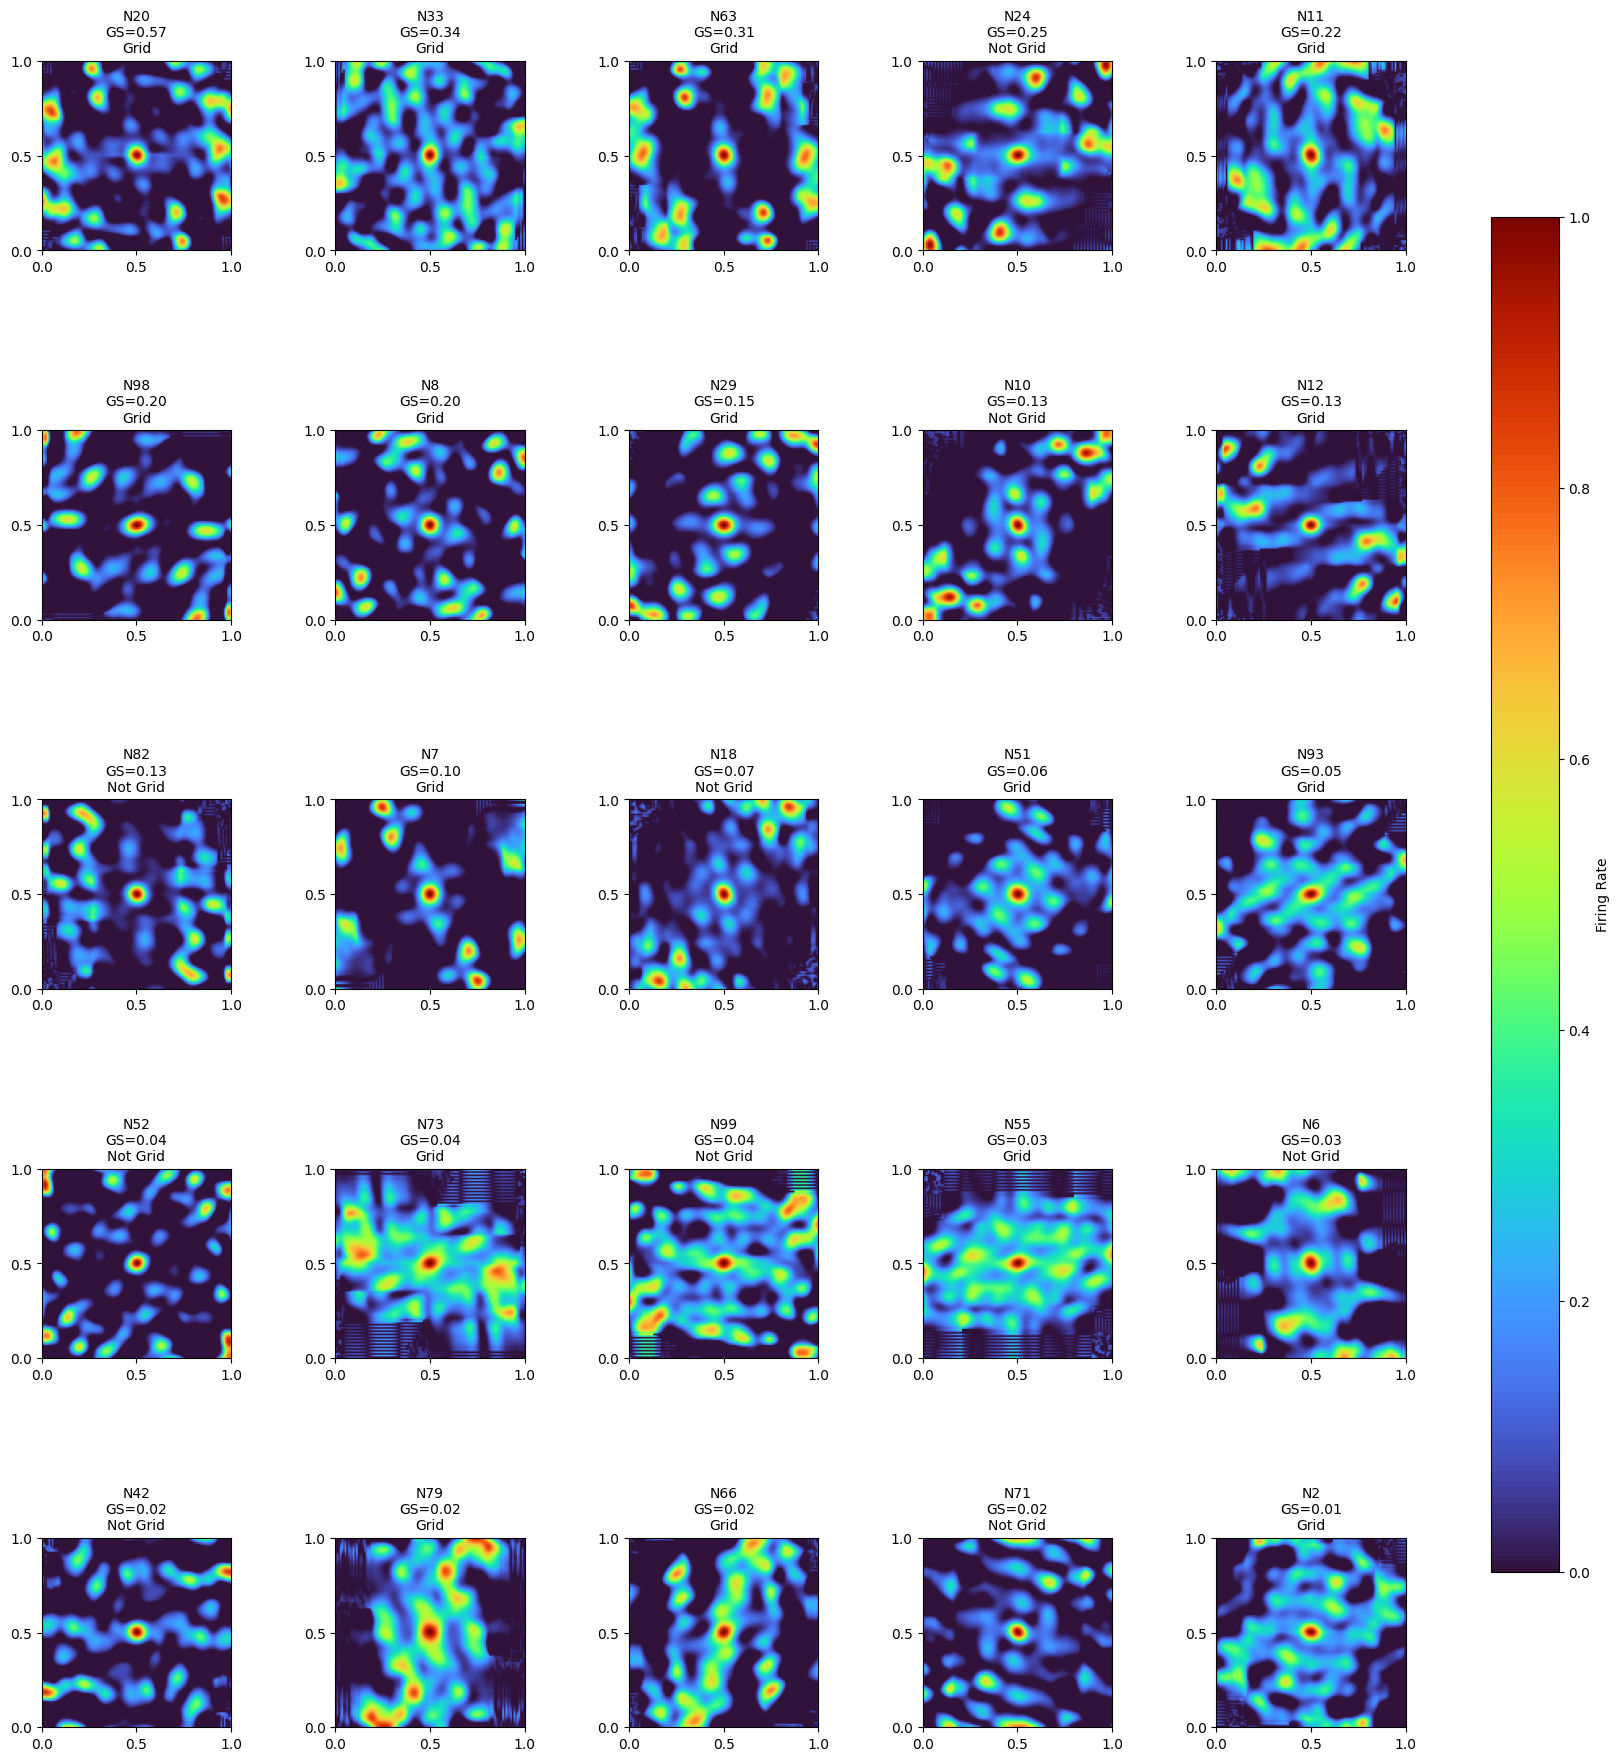

In [86]:
# -------------------------------------------------------
# Sort by Grid Score
# -------------------------------------------------------

grid_results = sorted(
    grid_results,
    key=lambda x: x["Grid Score"],
    reverse=True,
)

top25 = grid_results[:25]

print("Top 25 Grid Scores\n")

for g in top25:
    print(
        f"Neuron {g['Neuron']:3d} | "
        f"Grid Score = {g['Grid Score']:.3f} | "
        f"Threshold = {g['Threshold95']:.3f} | "
        f"Grid Cell = {g['Grid Cell']}"
    )

# -------------------------------------------------------
# Plot
# -------------------------------------------------------

fig, axes = plt.subplots(
    5,
    5,
    figsize=(22, 22),
)

plt.subplots_adjust(
    wspace=0.55,
    hspace=0.70,
)

axes = axes.ravel()

vmax = max(
    np.max(g["Autocorrelation"])
    for g in top25
)

for ax, neuron in zip(axes, top25):

    im = ax.imshow(
        neuron["Autocorrelation"],
        origin="lower",
        extent=[0, 1, 0, 1],
        cmap="turbo",
        aspect="equal",
        vmin=0,
        vmax=vmax,
    )

    ax.set_title(
        f"N{neuron['Neuron']}\n"
        f"GS={neuron['Grid Score']:.2f}\n"
        f"{'Grid' if neuron['Grid Cell'] else 'Not Grid'}",
        fontsize=10,
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_xticks([0, 0.5, 1])
    ax.set_yticks([0, 0.5, 1])

fig.colorbar(
    im,
    ax=axes.tolist(),
    shrink=0.8,
    label="Firing Rate",
)

plt.show()

In [ ]:
"""rng = np.random.default_rng(0)

for neuron in range(n_neurons):

    responses = combined_data["activations"][:, neuron]

    # Place-cell map
    rate_map, extent = build_firing_rate_map(
        responses,
        combined_data["positions"],
        occupancy_map,
    )

    si = spatial_information(
        rate_map,
        occupancy_map,
    )

    sp = sparsity(
        rate_map,
        occupancy_map,
    )

    # ----------------------------
    # Grid-cell analysis
    # ----------------------------

    grid = score_single_neuron(
        responses=responses,
        pos=combined_data["positions"],
        occupancy_map=occupancy_map,
        num_shuffles=20,
        rng=rng,
        thresh_param=THRESHOLD_K,
        res_param=N_BINS,
    )
    

    results.append({

        "Neuron": neuron,

        "Rate Map": rate_map,

        "Extent": extent,

        "Spatial Information": si,

        "Sparsity": sp,

        "Grid Score": grid["original_hgs"],

        "Grid Threshold": grid["shuffle_threshold_95"],

        "Grid Cell": grid["is_grid_cell"],

        "Autocorrelation": grid["autocorr_map"],

        "Autocorrelation Ring": grid["autocorr_ring"],
    })"""

KeyboardInterrupt: 

In [ ]:
grid_cells = [r for r in results if r["Grid Cell"]]

print(f"Grid cells detected: {len(grid_cells)}")

for r in grid_cells:
    print(
        f"Neuron {r['Neuron']:3d} | "
        f"Grid Score = {r['Grid Score']:.3f} | "
        f"Threshold = {r['Grid Threshold']:.3f}"
    )